<a href="https://colab.research.google.com/github/kjmobile/lb2/blob/main/3_LM_Feature_engineering_and_regularization_Airfares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3. Feature Engineering and Regularization: Airfares

More features can make a model fit better, or fit **too** well: it learns the training markets by heart and
predicts new markets badly (**overfitting**). Regularization holds the model back.

Slides: W3.1, polynomial regression and regularization (Lasso and Ridge).

> **Data.** The 200 busiest U.S. domestic markets in 2019, read straight from the course GitHub repository.
> Source: Sabre Market Intelligence, licensed to Embry-Riddle.

## 1. Data Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

routes = pd.read_csv('https://raw.githubusercontent.com/kjmobile/lb2/main/data/sabre_routes_2019.csv')
routes.head()

,airport_1,airport_2,distance_mi,passengers,avg_fare,lcc_share,hhi,top_airline
0,JFK,LAX,2470.0,3115042.0,349.29,0.321,0.269,DL
1,LGA,ORD,731.0,2600397.0,174.47,0.086,0.293,AA
2,LAX,SFO,337.0,2289910.0,104.55,0.203,0.212,AS
3,LAX,ORD,1741.0,1853120.0,187.84,0.146,0.332,UA
4,LAS,LAX,236.0,1831441.0,73.20,0.438,0.180,WN


**What is `hhi`?** The **Herfindahl–Hirschman Index**, the standard measure of market concentration.
Square each airline's share of the market's passengers, then add them up:

$$HHI = \sum_i s_i^2 \qquad (s_i = \text{airline } i\text{'s share of passengers})$$

| Market | Shares | HHI |
|---|---|---|
| One airline carries everyone | 1.0 | 1.0 |
| Two airlines, half each | 0.5, 0.5 | 0.25 + 0.25 = 0.5 |
| Four airlines, a quarter each | 0.25 each | 4 × 0.0625 = 0.25 |

Here shares are fractions, so HHI runs from 0 to 1. News reports and U.S. merger reviews put shares in percent,
so the same index runs from 0 to 10,000 (two airlines at half each = 5,000).

In [2]:
# Target y: average fare.  Inputs X: distance, low-cost share, market concentration.
X = routes[['distance_mi', 'lcc_share', 'hhi']]
y = routes['avg_fare']
train_X, test_X, train_y, test_y = train_test_split(X, y, random_state=42)
print('train:', train_X.shape, ' test:', test_X.shape)

train: (150, 3)  test: (50, 3)


In [3]:
# Starting point: a plain multiple regression with the 3 inputs
m_line = LinearRegression()
m_line.fit(train_X, train_y)
print('train R2:', round(m_line.score(train_X, train_y), 3))
print('test R2: ', round(m_line.score(test_X, test_y), 3))

train R2: 0.742
test R2:  0.741


## 2. Feature Engineering: Polynomial Features

`PolynomialFeatures(degree=2)` adds every square and every product of two inputs, for example
`distance_mi^2` (a curve) and `distance_mi lcc_share` (low-cost competition matters more on longer routes?).

In [4]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(train_X)
train_poly = poly.transform(train_X)
test_poly = poly.transform(test_X)      # transform the test set with the same poly

print(train_poly.shape)
poly.get_feature_names_out()

(150, 9)


array(['distance_mi', 'lcc_share', 'hhi', 'distance_mi^2',
       'distance_mi lcc_share', 'distance_mi hhi', 'lcc_share^2',
       'lcc_share hhi', 'hhi^2'], dtype=object)

## 3. Train the Multiple Regression

In [5]:
m0 = LinearRegression()
m0.fit(train_poly, train_y)
print('train R2:', round(m0.score(train_poly, train_y), 3))
print('test R2: ', round(m0.score(test_poly, test_y), 3))

train R2: 0.777
test R2:  0.783


## 4. What if we raise the degree from 2 to 5?

In [6]:
poly_5 = PolynomialFeatures(degree=5, include_bias=False)
poly_5.fit(train_X)
train_poly_5 = poly_5.transform(train_X)
test_poly_5 = poly_5.transform(test_X)
print(train_poly_5.shape)

m1 = LinearRegression()
m1.fit(train_poly_5, train_y)
print('train R2:', round(m1.score(train_poly_5, train_y), 3))
print('test R2: ', round(m1.score(test_poly_5, test_y), 3))

(150, 55)
train R2: 0.824
test R2:  0.543


**Overfitting.** 3 inputs became 55 features for only 150 training markets. The train R² went **up**, the test
R² went **down**: the model memorized the training markets instead of learning the pattern.

$$R^2 = 1 - \frac{RSS}{TSS}$$

On the test set the misses (RSS) grew. If they grow past TSS, R² even turns negative.

---
# 5. Regularization

Regularization **stops the model from learning the training set too closely** by adding a penalty on the
size of the coefficients $w$. A larger $\lambda$ means a stronger penalty.

$$\text{Lasso (L1)}: \ \min\left(\text{Loss} + \lambda \sum |w|\right)
\qquad
\text{Ridge (L2)}: \ \min\left(\text{Loss} + \lambda \sum w^2\right)$$

In scikit-learn, $\lambda$ is called **`alpha`** (default 1.0).

### 5.1 Standardize first

The penalty depends on the size of each coefficient, so all features must be on the same scale.
**Standardization** turns each feature into mean 0 and standard deviation 1:

$$z = \frac{x-\mu}{\sigma}$$

In [7]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(train_poly_5)
train_scaled = ss.transform(train_poly_5)
test_scaled = ss.transform(test_poly_5)

### 5.2 Lasso: L1 regularization

In [8]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=100000)
lasso.fit(train_scaled, train_y)
print('train R2:', round(lasso.score(train_scaled, train_y), 3))
print('test R2: ', round(lasso.score(test_scaled, test_y), 3))

train R2: 0.783
test R2:  0.778


### 5.3 Choosing alpha (a hyperparameter)

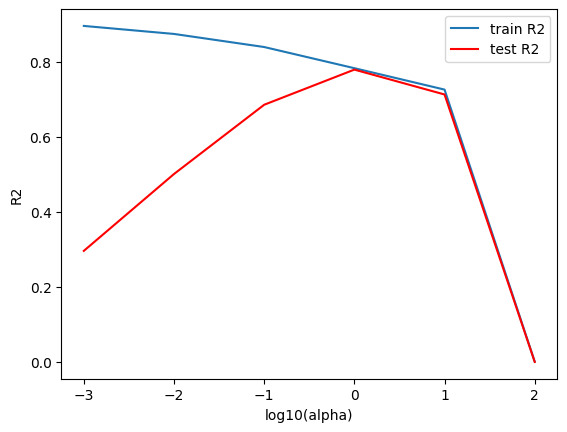

In [9]:
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
train_score_l = []
test_score_l = []

for alpha in alpha_list:
    lasso = Lasso(alpha=alpha, max_iter=1000000, tol=0.01)    # more steps, as in lb, so tiny alphas finish
    lasso.fit(train_scaled, train_y)
    train_score_l.append(lasso.score(train_scaled, train_y))
    test_score_l.append(lasso.score(test_scaled, test_y))

plt.plot(np.log10(alpha_list), train_score_l, label='train R2')
plt.plot(np.log10(alpha_list), test_score_l, color='red', label='test R2')
plt.xlabel('log10(alpha)')
plt.ylabel('R2')
plt.legend()
plt.show()

In [10]:
lasso = Lasso(alpha=1, max_iter=100000)
lasso.fit(train_scaled, train_y)
print('test R2:', round(lasso.score(test_scaled, test_y), 3))

print('features:', len(lasso.coef_))
print('coefficients set to 0:', np.sum(lasso.coef_ == 0))

test R2: 0.778
features: 55
coefficients set to 0: 47


Lasso set most coefficients to exactly 0. It **chose** the features to keep:

In [11]:
lasso_coef = pd.Series(lasso.coef_, poly_5.get_feature_names_out())
lasso_coef[lasso_coef != 0].round(1)

distance_mi                   7.3
lcc_share                   -14.5
distance_mi hhi              35.3
hhi^3                        -1.8
distance_mi^5                14.0
distance_mi^3 lcc_share^2    -0.3
distance_mi hhi^4            -9.5
lcc_share hhi^4               0.7
dtype: float64

### Your turn

Fit a Lasso model with `alpha=10` on the scaled training set and print its test R².

Fill in the blanks:

```python
lasso = _____(alpha=__, max_iter=100000)
lasso.fit(____________, _______)
print(lasso.score(___________, ______))
```

<details><summary>Show answer</summary>

```python
lasso = Lasso(alpha=10, max_iter=100000)
lasso.fit(train_scaled, train_y)
print(lasso.score(test_scaled, test_y))
```
</details>

In [12]:
# Write your code here

### 5.4 Ridge: L2 regularization

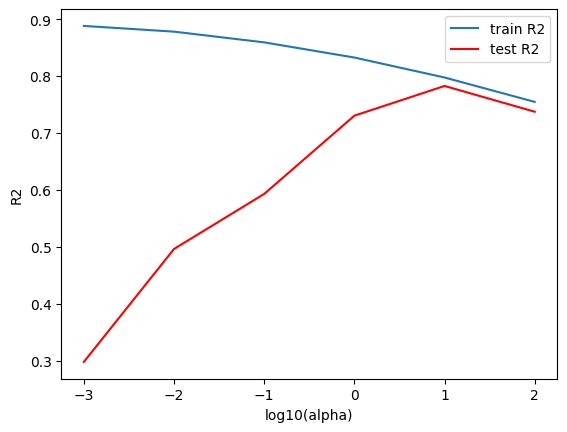

In [13]:
from sklearn.linear_model import Ridge

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
train_score_r = []
test_score_r = []

for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_y)
    train_score_r.append(ridge.score(train_scaled, train_y))
    test_score_r.append(ridge.score(test_scaled, test_y))

plt.plot(np.log10(alpha_list), train_score_r, label='train R2')
plt.plot(np.log10(alpha_list), test_score_r, color='red', label='test R2')
plt.xlabel('log10(alpha)')
plt.ylabel('R2')
plt.legend()
plt.show()

In [14]:
ridge = Ridge(alpha=10)
ridge.fit(train_scaled, train_y)
print('test R2:', round(ridge.score(test_scaled, test_y), 3))

# Ridge shrinks coefficients but keeps all of them
print('features:', len(ridge.coef_))
print('coefficients set to 0:', np.sum(ridge.coef_ == 0))

test R2: 0.783
features: 55
coefficients set to 0: 0


## 6. Summary

| Model | Features | Test R² |
|---|---|---|
| Straight multiple regression | 3 | about 0.74 |
| Degree 2 | 9 | about 0.78 |
| Degree 5 | 55 | about 0.54 (overfitting) |
| Degree 5 + Lasso, alpha = 1 | 55 (most set to 0) | about 0.78 |
| Degree 5 + Ridge, alpha = 10 | 55 (all shrunk) | about 0.78 |

- **Lasso** sets weak coefficients to exactly 0, so it also selects features.
- **Ridge** shrinks all coefficients but keeps them.

---
# Challenge

1. In the Ridge loop, which `alpha` gives the best test R²? Try values between 1 and 100 (for example 5, 20, 50).
2. Look at the features Lasso kept. Which input appears most often? What does that say about what sets airfares?

In [15]:
# Your answer